In [1]:
import numpy as np 
import pandas as pd
import os


In [2]:
import shutil
#delete existing files
shutil.rmtree("/kaggle/working/train_subset", ignore_errors=True)
shutil.rmtree("/kaggle/working/val_subset", ignore_errors=True)

print("Old subsets deleted")

Old subsets deleted


In [3]:

#create directories
os.makedirs("/kaggle/working/train_subset/images", exist_ok=True)
os.makedirs("/kaggle/working/train_subset/masks", exist_ok=True)

os.makedirs("/kaggle/working/val_subset/images", exist_ok=True)
os.makedirs("/kaggle/working/val_subset/masks", exist_ok=True)

In [4]:
import random


BASE = "/kaggle/input/datasets/tekbahadurkshetri/landslide4sense"

img_dir = BASE + "/TrainData/img"
mask_dir = BASE + "/TrainData/mask"

out_train_img = "/kaggle/working/train_subset/images"
out_train_mask = "/kaggle/working/train_subset/masks"

out_val_img = "/kaggle/working/val_subset/images"
out_val_mask = "/kaggle/working/val_subset/masks"

for p in [out_train_img, out_train_mask, out_val_img, out_val_mask]:
    os.makedirs(p, exist_ok=True)

img_files = sorted(os.listdir(img_dir))
mask_files = sorted(os.listdir(mask_dir))

#pair and then shuffle
pairs = list(zip(img_files, mask_files))

random.shuffle(pairs)

train_pairs = pairs[:700]
val_pairs = pairs[700:830]

# copy train
for img_f, mask_f in train_pairs:
    shutil.copy(os.path.join(img_dir, img_f), os.path.join(out_train_img, img_f))
    shutil.copy(os.path.join(mask_dir, mask_f), os.path.join(out_train_mask, img_f))  

# copy val
for img_f, mask_f in val_pairs:
    shutil.copy(os.path.join(img_dir, img_f), os.path.join(out_val_img, img_f))
    shutil.copy(os.path.join(mask_dir, mask_f), os.path.join(out_val_mask, img_f))

print("Subset created successfully!")

Subset created successfully!


In [5]:
train_img = "/kaggle/working/train_subset/images"
train_mask = "/kaggle/working/train_subset/masks"

val_img = "/kaggle/working/val_subset/images"
val_mask = "/kaggle/working/val_subset/masks"

print("TRAIN → images:", len(os.listdir(train_img)))
print("TRAIN → masks :", len(os.listdir(train_mask)))

print("VAL   → images:", len(os.listdir(val_img)))
print("VAL   → masks :", len(os.listdir(val_mask)))

TRAIN → images: 700
TRAIN → masks : 700
VAL   → images: 130
VAL   → masks : 130


In [6]:
import h5py
import torch
from torch.utils.data import Dataset

# Selected bands (B2, B3, B5, B7, B8, B9)
CHANNELS = [1, 2, 4, 6, 7, 8]

class LandslideDataset(Dataset):
    def __init__(self, img_dir, mask_dir,transform=None):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        with h5py.File(self.img_paths[idx], 'r') as f:
            img = f['img'][:]   

        with h5py.File(self.mask_paths[idx], 'r') as f:
            mask = f['mask'][:]

        img = img[:, :, CHANNELS]
        img = img / np.max(img)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        img = torch.tensor(img).permute(2, 0, 1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [7]:
!pip install albumentations
import albumentations as A
#augmentation
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

In [8]:
from torch.utils.data import DataLoader

train_dataset = LandslideDataset(
    "/kaggle/working/train_subset/images",
    "/kaggle/working/train_subset/masks",transform=transform
)

val_dataset = LandslideDataset(
    "/kaggle/working/val_subset/images",
    "/kaggle/working/val_subset/masks",transform=None
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

In [9]:
img, mask = train_dataset[0]
print(img.shape)
print(mask.shape)

torch.Size([6, 128, 128])
torch.Size([1, 128, 128])


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),#recognize features
            nn.BatchNorm2d(out_ch),#stabilize training
            nn.ReLU(inplace=True),#adds non-linearity
            nn.Dropout2d(p=0.3),   

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.3)    
        )

    def forward(self, x):
        return self.conv(x)

class UNetResNet34(nn.Module):
    def __init__(self, in_channels=6, num_classes=1):
        super().__init__()

        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        self.encoder0 = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.encoder1 = resnet.layer1   #64 channels
        self.encoder2 = resnet.layer2   #128 channels
        self.encoder3 = resnet.layer3   #256 channels
        self.encoder4 = resnet.layer4   #512 channels

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder4 = ConvBlock(512, 256)

        self.upconv3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder3 = ConvBlock(256, 128)

        self.upconv2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder2 = ConvBlock(128, 64)

        self.upconv1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.decoder1 = ConvBlock(96, 32)

        self.final = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e0 = self.encoder0(x)
        e1 = self.encoder1(self.maxpool(e0))
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        d4 = self.upconv4(e4)
        d4 = F.interpolate(d4, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.decoder4(d4)

        d3 = self.upconv3(d4)
        d3 = F.interpolate(d3, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upconv2(d3)
        d2 = F.interpolate(d2, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upconv1(d2)
        d1 = F.interpolate(d1, size=e0.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e0], dim=1)
        d1 = self.decoder1(d1)

        out = self.final(d1)

        
        out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=False)

        return out

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetResNet34(in_channels=6, num_classes=1).to(device)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 214MB/s]


In [12]:
# Freeze entire model 
for param in model.parameters():
    param.requires_grad = False

# Unfreeze decoder
for name, param in model.named_parameters():
    if "encoder" not in name:
        param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)


# Check trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Trainable %:", 100 * trainable / total)

Trainable %: 12.561038810867734


In [13]:

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    
    dice = (2 * intersection + 1e-8) / (union + 1e-8)
    return 1 - dice.mean()

pos_weight = torch.tensor([2.0]).to(device)

def combined_loss(pred, target):
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(pred, target)
    dloss = dice_loss(pred, target)
    return bce + dloss

criterion = combined_loss

def precision_recall(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()

    TP = (pred * target).sum()
    FP = (pred * (1 - target)).sum()
    FN = ((1 - pred) * target).sum()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    return precision.item(), recall.item()


In [14]:
EPOCHS = 15
best_dice = 0.0
best_precision = 0.0
best_recall = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # Validation
    model.eval()
    val_loss = 0
    val_dice = 0
    val_precision = 0
    val_recall = 0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, masks)
            val_loss += loss.item()

            # Dice calculation
            preds = (torch.sigmoid(outputs) > 0.5).float()
            intersection = (preds * masks).sum()
            union = preds.sum() + masks.sum()
            dice = (2 * intersection / (union + 1e-8)).item()

            val_dice += dice
            precision, recall = precision_recall(outputs, masks)
            val_precision += precision
            val_recall += recall

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_precision /= len(val_loader)
    val_recall /= len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Dice: {val_dice:.4f}")
    print("-" * 30)

    # Save Best model
    if val_dice > best_dice:
        best_dice = val_dice
        best_precision = val_precision
        best_recall = val_recall

        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved")

print(f"\nBest Dice Score: {best_dice:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")

Epoch 1/15
Train Loss: 1.1993
Val Loss: 1.1915
Dice: 0.2355
------------------------------
Best model saved
Epoch 2/15
Train Loss: 0.9727
Val Loss: 0.9125
Dice: 0.3772
------------------------------
Best model saved
Epoch 3/15
Train Loss: 0.8988
Val Loss: 0.8773
Dice: 0.3879
------------------------------
Best model saved
Epoch 4/15
Train Loss: 0.8759
Val Loss: 0.8289
Dice: 0.4248
------------------------------
Best model saved
Epoch 5/15
Train Loss: 0.8548
Val Loss: 0.8393
Dice: 0.3937
------------------------------
Epoch 6/15
Train Loss: 0.8478
Val Loss: 0.8333
Dice: 0.4058
------------------------------
Epoch 7/15
Train Loss: 0.8456
Val Loss: 0.8365
Dice: 0.4085
------------------------------
Epoch 8/15
Train Loss: 0.8423
Val Loss: 0.8157
Dice: 0.4387
------------------------------
Best model saved
Epoch 9/15
Train Loss: 0.8368
Val Loss: 0.8141
Dice: 0.4366
------------------------------
Epoch 10/15
Train Loss: 0.8310
Val Loss: 0.8102
Dice: 0.4409
------------------------------
Best

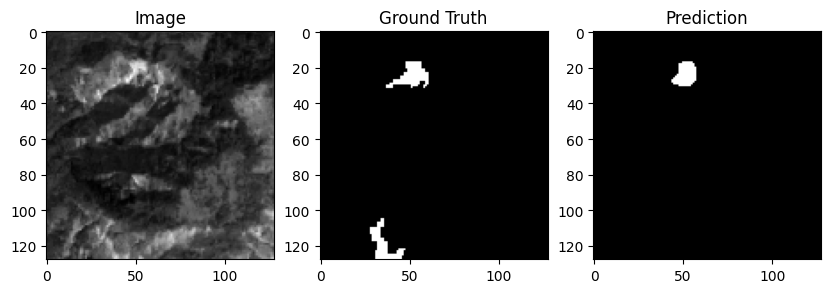

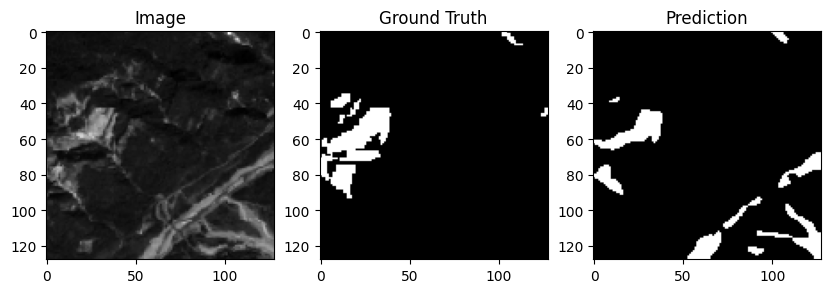

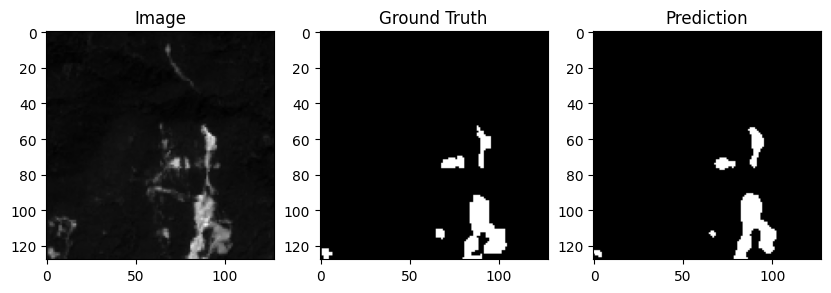

In [15]:
import matplotlib.pyplot as plt

model.eval()
imgs, masks = next(iter(val_loader))
imgs = imgs.to(device)

with torch.no_grad():
    outputs = model(imgs)
    preds = (torch.sigmoid(outputs) > 0.5).float()

imgs = imgs.cpu()
masks = masks.cpu()
preds = preds.cpu()

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(imgs[i][0], cmap='gray')

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(masks[i][0], cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(preds[i][0], cmap='gray')

    plt.show()

In [16]:
import os
print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'val_subset', 'best_model.pth', 'train_subset']
